In [3]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [5]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [6]:
df.shape

(100, 3)

In [7]:
df.head()

,feature1,feature2,target
0,-1.194115,0.170270,-100.209607
1,0.808724,0.049466,84.947415
2,-0.191798,-1.332812,-36.537729
3,-0.342876,0.534014,3.037503
4,-1.679676,-1.169235,-121.233244


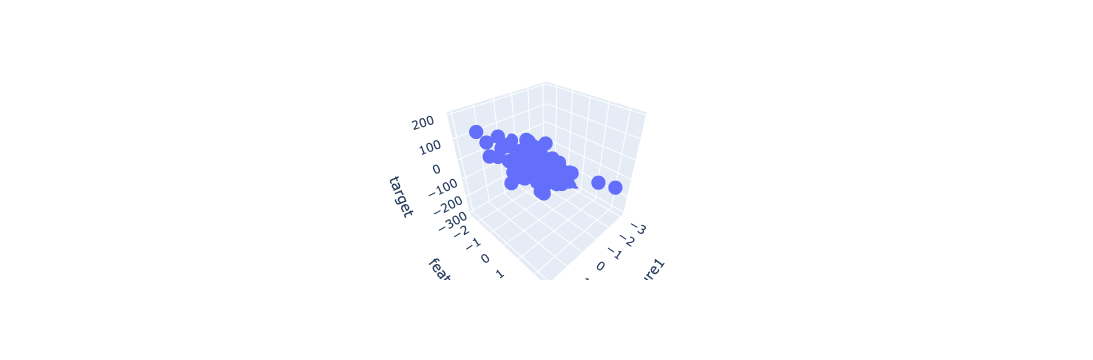

In [8]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [10]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = lr.predict(X_test)

In [15]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 47.22590669508806
MSE 3419.1083793093085
R2 score 0.6410360378069743


In [17]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

z = z_final



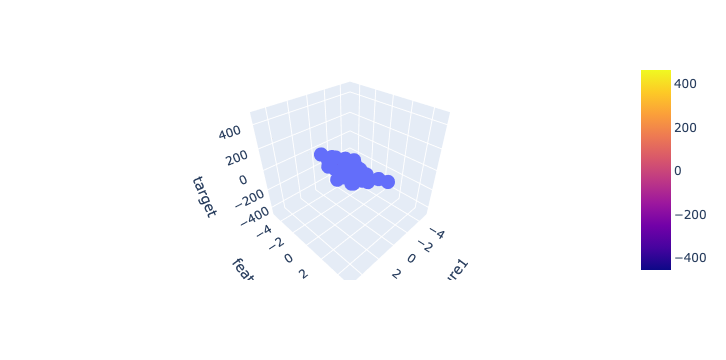

In [18]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [19]:
lr.coef_

array([78.94178346, 13.26764557])

In [20]:
lr.intercept_

np.float64(4.3479333465811365)